In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Laad de data (pas pad aan als nodig)
df = pd.read_csv('anonsecondfinal_real.csv', encoding='utf-8')

print(f"Shape: {df.shape}")
print(df.columns.tolist())
df.head()

Shape: (3331, 15)
['Ticket Number', 'Title', 'Queue', 'Issue Type', 'Sub-Issue Type', 'Priority', 'Created', 'Due', 'Total Hours Worked', 'Contract Type', 'Resolved Time', 'Source', 'Ticket Category', 'Ticket Type', 'Work Type']


,Ticket Number,Title,Queue,Issue Type,Sub-Issue Type,Priority,Created,Due,Total Hours Worked,Contract Type,Resolved Time,Source,Ticket Category,Ticket Type,Work Type
0,T20260518.0008,SRQ - CODE_001 - Reset MFA [naam - geanonimise...,10 - Level 1 - Servicedesk,SR - User management,Password/MFA reset,3 - Standard,5/18/2026 13:41,5/22/2026 15:41,0.25,Recurring Service,5/18/2026 13:48,Telephone,Service Request,Service Request,Non-standard Change
1,T20260518.0007,INC - CODE_001 - MFA Reset - [naam - geanonimi...,10 - Level 1 - Servicedesk,IM - User Management,Login issues,3 - Standard,5/18/2026 12:01,5/22/2026 14:01,0.00,Recurring Service,NaN,Telephone,Incident Management,Incident,Incident management
2,T20260518.0006,INC - CODE_001 - Outlook op werkmobiel werkt n...,10 - Level 1 - Servicedesk,IM - User Management,Login issues,3 - Standard,5/18/2026 11:59,5/22/2026 13:59,0.25,Recurring Service,NaN,Email,Incident Management,Incident,Incident management
3,T20260518.0005,INC - CODE_002 - [naam - geanonimiseerd] - AVD...,10 - Level 1 - Servicedesk,IM - Workstation,Performance,3 - Standard,5/18/2026 10:30,5/22/2026 12:30,0.00,Recurring Service,NaN,Telephone,Incident Management,Incident,Incident management
4,T20260518.0004,INC - CODE_002 - [naam - geanonimiseerd] - AVD...,10 - Level 1 - Servicedesk,IM - Workstation,Display,3 - Standard,5/18/2026 10:29,5/22/2026 12:29,0.00,Recurring Service,NaN,Telephone,Incident Management,Incident,Incident management


In [4]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# Datum conversie
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')
df['Resolved Time'] = pd.to_datetime(df['Resolved Time'], errors='coerce')

# Nieuwe kolommen
df['YearMonth'] = df['Created'].dt.to_period('M')
df['Resolution Time (hours)'] = (df['Resolved Time'] - df['Created']).dt.total_seconds() / 3600

<class 'pandas.DataFrame'>
RangeIndex: 3331 entries, 0 to 3330
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ticket Number       3331 non-null   str    
 1   Title               3331 non-null   str    
 2   Queue               3331 non-null   str    
 3   Issue Type          3286 non-null   str    
 4   Sub-Issue Type      2577 non-null   str    
 5   Priority            3331 non-null   str    
 6   Created             3331 non-null   str    
 7   Due                 3317 non-null   str    
 8   Total Hours Worked  3331 non-null   float64
 9   Contract Type       3278 non-null   str    
 10  Resolved Time       3256 non-null   str    
 11  Source              3164 non-null   str    
 12  Ticket Category     3331 non-null   str    
 13  Ticket Type         3331 non-null   str    
 14  Work Type           3231 non-null   str    
dtypes: float64(1), str(14)
memory usage: 390.5 KB
None

Missing values

In [5]:
# === CEL 3: Overzicht meest voorkomende tickets (kandidaat-scenario’s voor PoC) ===
print("Top 15 Ticket Categories:")
print(df['Ticket Category'].value_counts().head(15))

print("\nTop Incident Types:")
print(df['Issue Type'].value_counts().head(10))

# Groeperen op combinatie Issue Type + Sub-Issue Type
top_combos = df.groupby(['Issue Type', 'Sub-Issue Type']).size().reset_index(name='Count')
top_combos = top_combos.sort_values('Count', ascending=False).head(20)
print(top_combos)

Top 15 Ticket Categories:
Ticket Category
Service Request        2115
Incident Management    1216
Name: count, dtype: int64

Top Incident Types:
Issue Type
SR - User management            705
SR - Software & Applications    557
IM - Maintenance                390
SR - Microsoft 365              245
SR - Workstation                186
IM - Network                    143
IM - Workstation                130
IM - Security                   115
SR - Maintenance                112
SR - Network                     99
Name: count, dtype: int64
                         Issue Type                  Sub-Issue Type  Count
113            SR - User management                 Onboarding user    205
115            SR - User management                     Permissions    175
112            SR - User management                Offboarding user    173
107    SR - Software & Applications                           Other    160
70               SR - Microsoft 365                 Exchange online    132
67      

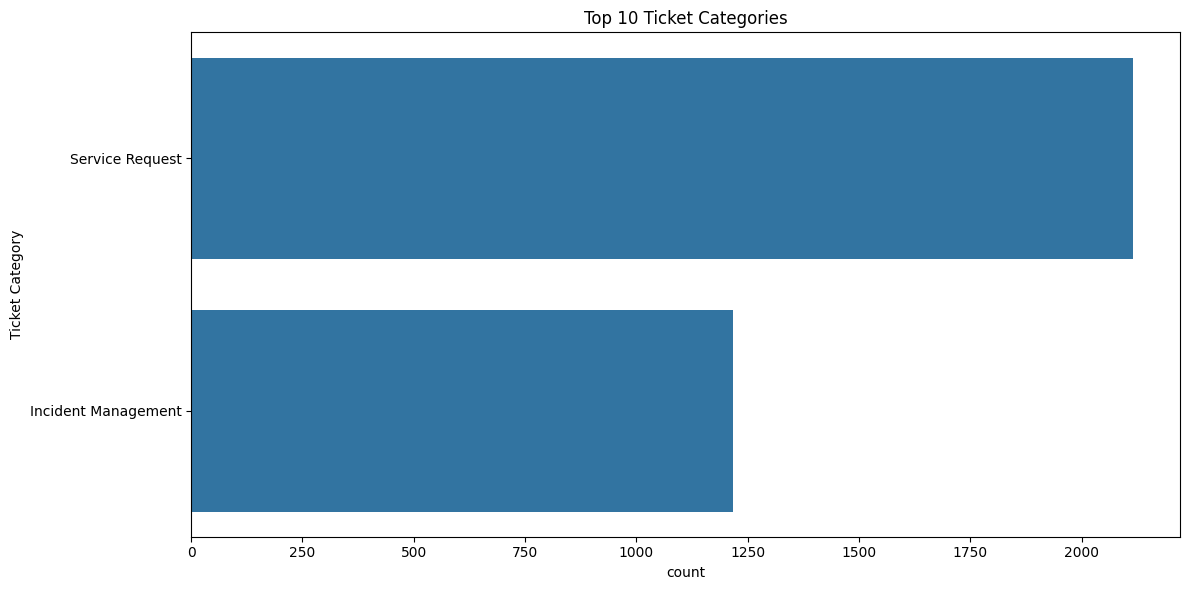

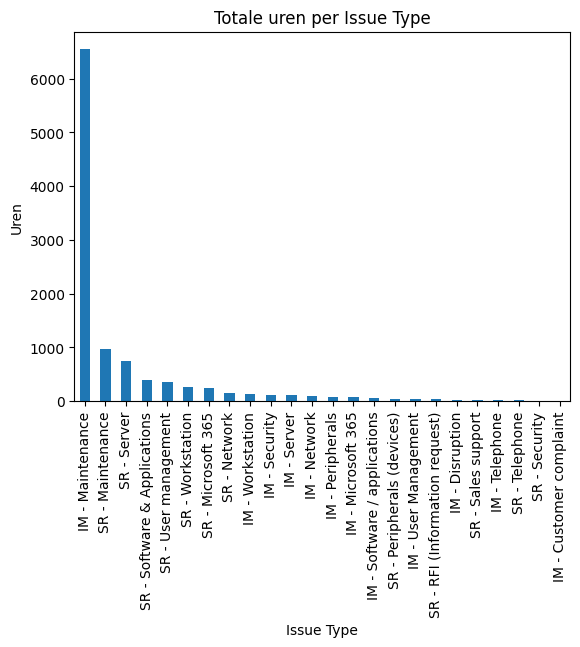

In [6]:
# === CEL 4: Visualisaties ===
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Ticket Category', order=df['Ticket Category'].value_counts().index[:10])
plt.title('Top 10 Ticket Categories')
plt.tight_layout()
plt.show()

# Uren per type
hours_by_type = df.groupby('Issue Type')['Total Hours Worked'].sum().sort_values(ascending=False)
hours_by_type.plot(kind='bar')
plt.title('Totale uren per Issue Type')
plt.ylabel('Uren')
plt.show()

In [7]:
# === CEL 5: Potentiële automatiseringsscenario’s ===
# Voorbeeld: schijfruimte, MFA, onboarding/offboarding, printer, etc.
patterns = ['Disk', 'MFA', 'Password', 'Onboarding', 'Offboarding', 'Printer', 'VPN', 'Outlook', 'AVD']

for pat in patterns:
    mask = df['Title'].str.contains(pat, case=False, na=False)
    count = mask.sum()
    hours = df.loc[mask, 'Total Hours Worked'].sum()
    print(f"{pat}: {count} tickets, {hours:.1f} uur")

Disk: 7 tickets, 4.8 uur
MFA: 57 tickets, 23.8 uur
Password: 55 tickets, 18.2 uur
Onboarding: 199 tickets, 122.0 uur
Offboarding: 141 tickets, 76.2 uur
Printer: 55 tickets, 68.5 uur
VPN: 57 tickets, 50.0 uur
Outlook: 42 tickets, 29.0 uur
AVD: 8 tickets, 4.0 uur


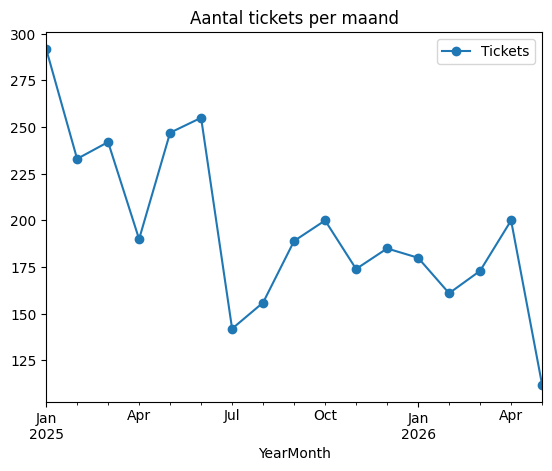

In [8]:
# === CEL 6: Tijdstrends ===
monthly = df.groupby('YearMonth').size().reset_index(name='Tickets')
monthly.plot(x='YearMonth', y='Tickets', kind='line', marker='o')
plt.title('Aantal tickets per maand')
plt.show()